## AlphaGenome disruption score-based clustering analysis

In [1]:
import os
import sys
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

analysis_dir = Path("../scripts/analysis").resolve()
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

import msi_classifier
importlib.reload(msi_classifier)


<module 'msi_classifier' from '/Users/an36943/PhD/Projects/cancer_non_coding/scripts/analysis/msi_classifier.py'>

In [2]:
PATIENT_SCORES = "../data/alphagenome_scores/patient_tissue_tracks_local/patient_tissue_track_scores.csv"
DRIVER_GENE_COORDS_DIR = Path("../data/driver_genes_coords")
PANCANCER_GENE_COORDS = DRIVER_GENE_COORDS_DIR / "Pancancer_1pc.tsv"
TISSUE_MAPPING = "../metadata/cancer_tissue_alphagenome_tracks.tsv"
CLINICAL_DATA = "../data/TCGA/survival/TCGA_survival_outcome.csv"
COAD_MSI_DATA = "../data/TCGA/msi_data/tcga_coad_msi_matched.csv"
UCEC_MSI_DATA = "../data/TCGA/msi_data/tcga_ucec_msi_matched.csv"
STAD_MSI_DATA = "../data/TCGA/msi_data/tcga_stad_msi_matched.csv"
TMB_DATA_DIR = "../data/TCGA/tcga_patient_variants_by_cancer"

AG_MODEL_INPUT = "../results/alphagenome_model_input"
AG_COX = "../results/alphagenome_cox_model"
os.makedirs(AG_MODEL_INPUT, exist_ok=True)
os.makedirs(AG_COX, exist_ok=True)
COMBINED_SCORES = os.path.join(AG_MODEL_INPUT, "combined_patient_scores.csv")


In [3]:
# Select one or more TCGA cancer types, or use None/[] for a pan-cancer model.
# SELECTED_CANCER_TYPE = ["BRCA"]
SELECTED_CANCER_TYPE = None
MISSING_THRESHOLD = 0.1

In [4]:

def print_permanova(data, groups, label, space, permutations=999, random_state=42):
    """Print a Euclidean PERMANOVA for a feature matrix and group labels."""
    data = np.asarray(data, dtype=float)
    groups = np.asarray(groups)
    valid = pd.notna(groups) & np.isfinite(data).all(axis=1)
    data, groups = data[valid], groups[valid]
    _, group_codes = np.unique(groups.astype(str), return_inverse=True)
    n_groups = group_codes.max() + 1
    n_samples = len(data)
    if n_groups < 2 or n_samples <= n_groups:
        print(f"{label} PERMANOVA ({space}): insufficient groups or samples.")
        return

    total_ss = ((data - data.mean(axis=0)) ** 2).sum()

    def pseudo_f(codes):
        counts = np.bincount(codes, minlength=n_groups)
        sums = np.vstack([
            np.bincount(codes, weights=data[:, dim], minlength=n_groups)
            for dim in range(data.shape[1])
        ]).T
        centroids = sums / counts[:, None]
        within_ss = ((data - centroids[codes]) ** 2).sum()
        between_ss = total_ss - within_ss
        return (between_ss / (n_groups - 1)) / (within_ss / (n_samples - n_groups))

    observed_f = pseudo_f(group_codes)
    rng = np.random.default_rng(random_state)
    permuted_f = np.array([pseudo_f(rng.permutation(group_codes)) for _ in range(permutations)])
    p_value = (np.sum(permuted_f >= observed_f) + 1) / (permutations + 1)
    print(
        f"{label} PERMANOVA ({space}): "
        f"pseudo-F={observed_f:.3f}, p={p_value:.4g}, permutations={permutations}"
    )

def print_tsne_permanova(df, group_col, label, feature_matrix, permutations=999):
    groups = df[group_col].to_numpy()
    print_permanova(
        df[["tsne_1", "tsne_2"]], groups, label, "t-SNE coordinates", permutations
    )
    print_permanova(
        feature_matrix, groups, label, "original scaled feature matrix", permutations
    )

## AlphaGenome derived gene-modality disruption scores

In [5]:
patient_scores_df = pd.read_csv(PATIENT_SCORES)
if SELECTED_CANCER_TYPE is None:
    selected_cancer_types = []
elif isinstance(SELECTED_CANCER_TYPE, str):
    selected_cancer_types = [SELECTED_CANCER_TYPE]
else:
    selected_cancer_types = [str(cancer_type) for cancer_type in SELECTED_CANCER_TYPE]

if selected_cancer_types:
    patient_scores_df = patient_scores_df[
        patient_scores_df["cancer_type"].astype(str).isin(selected_cancer_types)
    ].copy()
    allowed_driver_pairs = []
    for cancer_type in selected_cancer_types:
        gene_coords_path = DRIVER_GENE_COORDS_DIR / f"{cancer_type}.tsv"
        if not gene_coords_path.is_file():
            raise FileNotFoundError(
                f"No cancer-specific driver-gene coordinates found for {cancer_type}: "
                f"{gene_coords_path}"
            )
        driver_genes = set(pd.read_csv(gene_coords_path, sep="\t")["gene"].dropna().astype(str))
        available_genes = set(
            patient_scores_df.loc[
                patient_scores_df["cancer_type"].astype(str) == cancer_type, "gene"
            ].dropna().astype(str)
        )
        usable_genes = sorted(driver_genes & available_genes)
        missing_genes = sorted(driver_genes - available_genes)
        print(
            f"{cancer_type}: using {len(usable_genes)}/{len(driver_genes)} driver genes "
            f"with disruption data; ignoring {len(missing_genes)} without data."
        )
        allowed_driver_pairs.extend(
            {"cancer_type": cancer_type, "gene": gene} for gene in usable_genes
        )
    if not allowed_driver_pairs:
        raise ValueError("No selected cancer-type driver genes have disruption data")
    allowed_driver_pairs = pd.DataFrame(allowed_driver_pairs).drop_duplicates()
    patient_scores_df = patient_scores_df.merge(
        allowed_driver_pairs,
        on=["cancer_type", "gene"],
        how="inner",
        validate="many_to_one",
    )
else:
    pancancer_genes = set(
        pd.read_csv(PANCANCER_GENE_COORDS, sep="\t")["gene"].dropna().astype(str)
    )
    available_genes = set(patient_scores_df["gene"].dropna().astype(str))
    usable_genes = pancancer_genes & available_genes
    patient_scores_df = patient_scores_df[
        patient_scores_df["gene"].astype(str).isin(usable_genes)
    ].copy()
    print(
        f"Pan-cancer: using {len(usable_genes)}/{len(pancancer_genes)} driver genes "
        f"with disruption data."
    )

print(patient_scores_df.shape)
patient_scores_df.head()

Pan-cancer: using 31/31 driver genes with disruption data.
(16828022, 28)


,patient_id,cancer_type,gene,gene_strand,output_type,scorer,aggregation_type,score_region,score,n_tracks,...,selected_strand,mutations,interval_chrom,interval_start,interval_end,score_start,score_end,mean_abs_delta,max_abs_delta,mean_delta
0,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,0.000003,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000045,0.06250,0.000003
1,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000001,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000063,0.06250,-0.000001
2,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000002,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000029,0.03125,-0.000002
3,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,0.000003,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000065,0.12500,0.000003
4,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000625,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000809,4.00000,-0.000625


In [6]:
# strand specific track scores
patient_track_scores = patient_scores_df[patient_scores_df["scorer"] == "PATIENT_SINGLE_TRACK_SCORER"].copy()
patient_track_scores = patient_track_scores[~patient_track_scores[["patient_id", "cancer_type", "gene", "gene_strand", "output_type", "track_strand", "aggregation_type", "score"]].duplicated(keep=False)]
print(patient_track_scores.shape)
patient_track_scores.drop_duplicates(inplace=True)
print(patient_track_scores.shape)
# when there are tracks matching gene strand, select those, otherwise select track strand '.'
patient_track_scores = patient_track_scores[
    (patient_track_scores["track_strand"] == patient_track_scores["gene_strand"]) |
    (patient_track_scores["track_strand"] == ".")
].copy()
patient_track_scores["raw_score"] = patient_track_scores["score"]
patient_track_scores["score"] = pd.to_numeric(patient_track_scores["score"], errors="coerce")
unparseable_scores = patient_track_scores["raw_score"].notna() & patient_track_scores["score"].isna()
if unparseable_scores.any():
    debug_cols = ["patient_id", "cancer_type", "gene", "output_type", "aggregation_type", "raw_score"]
    print(
        f"Dropped {int(unparseable_scores.sum())} unparseable score rows; "
        f"examples: {patient_track_scores.loc[unparseable_scores, debug_cols].head(5).to_dict(orient='records')}"
    )
patient_track_scores = patient_track_scores.dropna(subset=["score"]).drop(columns=["raw_score"])
print(patient_track_scores.shape)
patient_track_scores.head()



(13007447, 28)
(13007447, 28)
(8992879, 28)


,patient_id,cancer_type,gene,gene_strand,output_type,scorer,aggregation_type,score_region,score,n_tracks,...,selected_strand,mutations,interval_chrom,interval_start,interval_end,score_start,score_end,mean_abs_delta,max_abs_delta,mean_delta
4,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000625,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000809,4.0,-0.000625
5,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000421,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000647,4.0,-0.000421
6,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000817,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000979,8.0,-0.000817
7,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,DIFF_MEAN,gene,-0.000479,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000660,4.0,-0.000479
13,TCGA-02-0016,GBM,TP53,-,CAGE,PATIENT_SINGLE_TRACK_SCORER,L2_DIFF,gene,6.342962,1.0,...,-,17:7479111-7479111:A:C;17:7636860-7636860:G:T;...,chr17,7150370,8198946,7661778,7687538,0.000809,4.0,-0.000625


In [7]:
# for L2_DIFF, get mean and median scores across all tracks for each patient-gene-output combination
patient_l2_diff_scores = patient_track_scores[patient_track_scores["aggregation_type"] == "L2_DIFF"]
patient_l2_diff_scores = patient_l2_diff_scores.groupby(["patient_id", "cancer_type", "gene", "output_type"])["score"].agg(['mean', 'median']).reset_index()
print(patient_l2_diff_scores.shape)
patient_l2_diff_scores.head()

(1641275, 6)


,patient_id,cancer_type,gene,output_type,mean,median
0,TCGA-02-0016,GBM,APC,CAGE,4.559749,4.414733
1,TCGA-02-0016,GBM,APC,CHIP_HISTONE,27.468669,16.000459
2,TCGA-02-0016,GBM,APC,DNASE,0.272520,0.241892
3,TCGA-02-0016,GBM,APC,RNA_SEQ,0.738063,0.745887
4,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,0.008201,0.008194


In [8]:
# Convert L2_DIFF summary statistics into long feature rows while keeping gene/output identifiers.
l2_diff_feature_scores = patient_l2_diff_scores.melt(
    id_vars=["patient_id", "cancer_type", "gene", "output_type"],
    value_vars=["mean", "median"],
    var_name="statistic",
    value_name="score",
)
l2_diff_feature_scores["feature"] = (
    "L2_DIFF__"
    + l2_diff_feature_scores["statistic"].astype(str)
    + "__"
    + l2_diff_feature_scores["gene"].astype(str)
    + "__"
    + l2_diff_feature_scores["output_type"].astype(str)
)
print(l2_diff_feature_scores.shape)
l2_diff_feature_scores.head()

(3282550, 7)


,patient_id,cancer_type,gene,output_type,statistic,score,feature
0,TCGA-02-0016,GBM,APC,CAGE,mean,4.559749,L2_DIFF__mean__APC__CAGE
1,TCGA-02-0016,GBM,APC,CHIP_HISTONE,mean,27.468669,L2_DIFF__mean__APC__CHIP_HISTONE
2,TCGA-02-0016,GBM,APC,DNASE,mean,0.272520,L2_DIFF__mean__APC__DNASE
3,TCGA-02-0016,GBM,APC,RNA_SEQ,mean,0.738063,L2_DIFF__mean__APC__RNA_SEQ
4,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,mean,0.008201,L2_DIFF__mean__APC__SPLICE_SITE_USAGE


In [9]:
# for DIFF_MEAN, get the distribution statistics for each patient-gene-output combination
patient_diff_mean_scores = patient_track_scores[patient_track_scores["aggregation_type"] == "DIFF_MEAN"]
patient_diff_mean_scores = (
    patient_diff_mean_scores
    .groupby(["patient_id", "cancer_type", "gene", "output_type"], as_index=False)
    .agg(
        min=("score", "min"),
        q25=("score", lambda x: np.percentile(x, 25)),
        median=("score", "median"),
        q75=("score", lambda x: np.percentile(x, 75)),
        max=("score", "max"),
        abs_max=("score", lambda x: np.max(np.abs(x))),
    )
)
print(patient_diff_mean_scores.shape)
patient_diff_mean_scores.head()

(1641229, 10)


,patient_id,cancer_type,gene,output_type,min,q25,median,q75,max,abs_max
0,TCGA-02-0016,GBM,APC,CAGE,-7.472187e-05,-5.846657e-05,-4.902110e-05,-4.055910e-05,-2.725422e-05,7.472187e-05
1,TCGA-02-0016,GBM,APC,CHIP_HISTONE,-3.436279e-02,-2.275848e-02,-9.502411e-03,6.254196e-03,2.536011e-02,3.436279e-02
2,TCGA-02-0016,GBM,APC,DNASE,-1.345202e-05,-5.202834e-06,-1.532026e-06,-1.983717e-07,1.039356e-06,1.345202e-05
3,TCGA-02-0016,GBM,APC,RNA_SEQ,8.851290e-06,3.276765e-05,4.386902e-05,5.225092e-05,6.800890e-05,6.800890e-05
4,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,-2.954039e-08,-2.192246e-08,-1.380249e-08,-6.537448e-09,-1.484295e-09,2.954039e-08


In [10]:
diff_mean_feature_scores = patient_diff_mean_scores.melt(
    id_vars=["patient_id", "cancer_type", "gene", "output_type"],
    value_vars=["min", "q25", "median", "q75", "max", "abs_max"],
    var_name="statistic",
    value_name="score",
)
diff_mean_feature_scores["feature"] = (
    "DIFF_MEAN__"
    + diff_mean_feature_scores["statistic"].astype(str)
    + "__"
    + diff_mean_feature_scores["gene"].astype(str)
    + "__"
    + diff_mean_feature_scores["output_type"].astype(str)
)
print(diff_mean_feature_scores.shape)
diff_mean_feature_scores.head()

(9847374, 7)


,patient_id,cancer_type,gene,output_type,statistic,score,feature
0,TCGA-02-0016,GBM,APC,CAGE,min,-7.472187e-05,DIFF_MEAN__min__APC__CAGE
1,TCGA-02-0016,GBM,APC,CHIP_HISTONE,min,-3.436279e-02,DIFF_MEAN__min__APC__CHIP_HISTONE
2,TCGA-02-0016,GBM,APC,DNASE,min,-1.345202e-05,DIFF_MEAN__min__APC__DNASE
3,TCGA-02-0016,GBM,APC,RNA_SEQ,min,8.851290e-06,DIFF_MEAN__min__APC__RNA_SEQ
4,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,min,-2.954039e-08,DIFF_MEAN__min__APC__SPLICE_SITE_USAGE


In [11]:
# Make a combined feature matrix with exactly one row per patient and one column per gene/output/statistic.
all_feature_scores = pd.concat(
    [
        l2_diff_feature_scores[["patient_id", "cancer_type", "feature", "score"]],
        diff_mean_feature_scores[["patient_id", "cancer_type", "feature", "score"]],
    ],
    ignore_index=True,
)

patient_metadata = (
    all_feature_scores[["patient_id", "cancer_type"]]
    .drop_duplicates()
    .sort_values(["patient_id", "cancer_type"])
)
if patient_metadata["patient_id"].duplicated().any():
    duplicated_patients = patient_metadata.loc[
        patient_metadata["patient_id"].duplicated(keep=False),
        "patient_id",
    ].unique()[:10]
    raise ValueError(
        "Some patients have multiple cancer_type values; cannot make one row per patient. "
        f"Examples: {duplicated_patients}"
    )

score_matrix = (
    all_feature_scores
    .pivot_table(
        index="patient_id",
        columns="feature",
        values="score",
        aggfunc="mean",
    )
    .reset_index()
)
score_matrix.columns.name = None
combined_scores = patient_metadata.merge(score_matrix, on="patient_id", how="right")
combined_scores = combined_scores[["patient_id", "cancer_type", *[c for c in combined_scores.columns if c not in {"patient_id", "cancer_type"}]]]

assert combined_scores["patient_id"].is_unique
print(combined_scores.shape)
# make all columns except patient_id and cancer_type into numeric, substitute missing values with nan
score_columns = [c for c in combined_scores.columns if c not in {"patient_id", "cancer_type"}]
combined_scores[score_columns] = combined_scores[score_columns].apply(pd.to_numeric, errors="coerce")
missing_score_values = int(combined_scores[score_columns].isna().sum().sum())
print(
    f"Retained {missing_score_values} absent feature values as NaN. "
    "No completion ledger is available for the pan-cancer combined score file, so absent rows are not zero-filled."
)
combined_scores.to_csv(COMBINED_SCORES, index=False)
combined_scores.head()




(8800, 1738)
Retained 2146876 absent feature values as NaN. No completion ledger is available for the pan-cancer combined score file, so absent rows are not zero-filled.


,patient_id,cancer_type,DIFF_MEAN__abs_max__APC__ATAC,DIFF_MEAN__abs_max__APC__CAGE,DIFF_MEAN__abs_max__APC__CHIP_HISTONE,DIFF_MEAN__abs_max__APC__CHIP_TF,DIFF_MEAN__abs_max__APC__DNASE,DIFF_MEAN__abs_max__APC__RNA_SEQ,DIFF_MEAN__abs_max__APC__SPLICE_SITE_USAGE,DIFF_MEAN__abs_max__ARID1A__ATAC,...,L2_DIFF__median__SMARCA4__DNASE,L2_DIFF__median__SMARCA4__RNA_SEQ,L2_DIFF__median__SMARCA4__SPLICE_SITE_USAGE,L2_DIFF__median__TP53__ATAC,L2_DIFF__median__TP53__CAGE,L2_DIFF__median__TP53__CHIP_HISTONE,L2_DIFF__median__TP53__CHIP_TF,L2_DIFF__median__TP53__DNASE,L2_DIFF__median__TP53__RNA_SEQ,L2_DIFF__median__TP53__SPLICE_SITE_USAGE
0,TCGA-02-0016,GBM,NaN,0.000075,0.034363,NaN,0.000013,0.000068,2.954039e-08,NaN,...,4.083036,10.514228,0.173857,NaN,5.773364,7.256462,NaN,0.208301,0.121599,0.008709
1,TCGA-02-0026,GBM,NaN,0.001227,2.119751,NaN,0.000525,0.001687,2.247107e-07,NaN,...,2.776144,5.813760,0.114389,NaN,39.345455,745.346222,NaN,2.735344,1.539053,0.052431
2,TCGA-02-0033,GBM,NaN,0.000061,0.135376,NaN,0.000011,0.000126,1.319713e-07,NaN,...,4.250876,4.628876,0.148689,NaN,31.971031,629.947983,NaN,2.387349,1.283309,0.027077
3,TCGA-02-0038,GBM,NaN,0.002493,5.358521,NaN,0.000871,0.006844,1.106149e-06,NaN,...,3.582028,4.555844,0.095753,NaN,38.822315,660.276840,NaN,2.114828,0.788526,0.042127
4,TCGA-02-0039,GBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.580953,4.464001,0.096468,NaN,34.100832,646.682861,NaN,2.310543,1.015487,0.029611


In [12]:
clinical_df = pd.read_csv(CLINICAL_DATA)
print(clinical_df.shape)
clinical_df = clinical_df.rename(columns={'bcr_patient_barcode': 'patient_id'})
clinical_df.head()

(11160, 34)


,Unnamed: 0,patient_id,type,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,...,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,1,TCGA-OR-A5J1,ACC,58.0,MALE,WHITE,Stage II,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],...,NaN,1.0,1355.0,1.0,1355.0,1.0,754.0,1.0,754.0,NaN
1,2,TCGA-OR-A5J2,ACC,44.0,FEMALE,WHITE,Stage IV,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],...,NaN,1.0,1677.0,1.0,1677.0,NaN,NaN,1.0,289.0,NaN
2,3,TCGA-OR-A5J3,ACC,23.0,FEMALE,WHITE,Stage III,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],...,NaN,0.0,2091.0,0.0,2091.0,1.0,53.0,1.0,53.0,NaN
3,4,TCGA-OR-A5J4,ACC,23.0,FEMALE,WHITE,Stage IV,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],...,NaN,1.0,423.0,1.0,423.0,NaN,NaN,1.0,126.0,NaN
4,5,TCGA-OR-A5J5,ACC,30.0,MALE,WHITE,Stage III,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],...,NaN,1.0,365.0,1.0,365.0,NaN,NaN,1.0,50.0,NaN


## Generic model input

In [13]:
# Prepare generic model input by merging combined scores with clinical survival data.
clinical_survival_df = clinical_df.copy()
required_clinical_cols = ["patient_id", "OS.time", "OS", "age_at_initial_pathologic_diagnosis", "gender"]
model_input_df = combined_scores.merge(
    clinical_survival_df[required_clinical_cols],
    on="patient_id",
    how="inner",
    validate="one_to_one",
)
model_input_df["age_at_initial_pathologic_diagnosis"] = pd.to_numeric(model_input_df["age_at_initial_pathologic_diagnosis"], errors="coerce")

model_input_df["OS.time"] = pd.to_numeric(model_input_df["OS.time"], errors="coerce")
model_input_df["OS"] = pd.to_numeric(model_input_df["OS"], errors="coerce")
model_input_df = model_input_df.dropna(subset=["OS.time", "OS"])
model_input_df = model_input_df[model_input_df["OS.time"] > 0]
model_input_df["OS"] = model_input_df["OS"].astype(int)

score_feature_cols = [col for col in combined_scores.columns if col not in {"patient_id", "cancer_type"}]
model_input_df = model_input_df[["patient_id", "cancer_type", "OS.time", "OS", "age_at_initial_pathologic_diagnosis", "gender", *score_feature_cols]].copy()

model_input_df = model_input_df.rename(columns={"age_at_initial_pathologic_diagnosis": "age"})
model_input_df["cancer_type"] = model_input_df["cancer_type"].astype(str)
model_input_df["gender"] = model_input_df["gender"].astype("category")

# Keep raw cancer_type as metadata for stratification/filtering, and add dummy columns separately for optional modeling.
model_design_df = pd.get_dummies(
    model_input_df,
    columns=["gender", "cancer_type"],
    drop_first=True,
    dummy_na=True,
)
model_design_df["cancer_type"] = model_input_df["cancer_type"].values

model_feature_cols = [col for col in model_design_df.columns if col not in {"patient_id", "cancer_type", "OS.time", "OS"}]
model_design_df[model_feature_cols] = model_design_df[model_feature_cols].apply(pd.to_numeric, errors="coerce")
print(model_design_df.shape)
model_design_df.head()

(8671, 1775)


,patient_id,OS.time,OS,age,DIFF_MEAN__abs_max__APC__ATAC,DIFF_MEAN__abs_max__APC__CAGE,DIFF_MEAN__abs_max__APC__CHIP_HISTONE,DIFF_MEAN__abs_max__APC__CHIP_TF,DIFF_MEAN__abs_max__APC__DNASE,DIFF_MEAN__abs_max__APC__RNA_SEQ,...,cancer_type_SKCM,cancer_type_STAD,cancer_type_TGCT,cancer_type_THCA,cancer_type_THYM,cancer_type_UCEC,cancer_type_UCS,cancer_type_UVM,cancer_type_nan,cancer_type
0,TCGA-02-0016,2648.0,1,50.0,NaN,0.000075,0.034363,NaN,0.000013,0.000068,...,False,False,False,False,False,False,False,False,False,GBM
1,TCGA-02-0026,748.0,1,27.0,NaN,0.001227,2.119751,NaN,0.000525,0.001687,...,False,False,False,False,False,False,False,False,False,GBM
2,TCGA-02-0033,86.0,1,54.0,NaN,0.000061,0.135376,NaN,0.000011,0.000126,...,False,False,False,False,False,False,False,False,False,GBM
3,TCGA-02-0038,326.0,1,48.0,NaN,0.002493,5.358521,NaN,0.000871,0.006844,...,False,False,False,False,False,False,False,False,False,GBM
4,TCGA-02-0039,320.0,1,54.0,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,GBM


In [14]:
# Filter first, then split. This keeps train/test preprocessing specific to the modeled cohort.
model_split_df = model_design_df.copy()
if selected_cancer_types:
    model_split_df = model_split_df[model_split_df["cancer_type"].isin(selected_cancer_types)].copy()

# For a cancer-specific model, stratify by event status so the test set has OS events/censored samples.
# For pan-cancer use, keep cancer types balanced across train/test.
stratify_col = model_split_df["OS"] if selected_cancer_types else model_split_df["cancer_type"]
train_df, test_df = train_test_split(
    model_split_df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col,
)
print(f"Selected cancer type: {SELECTED_CANCER_TYPE}; training set: {train_df.shape}, test set: {test_df.shape}")
print(f"Training OS events: {int(train_df['OS'].sum())}; test OS events: {int(test_df['OS'].sum())}")

Selected cancer type: None; training set: (6936, 1775), test set: (1735, 1775)
Training OS events: 1961; test OS events: 516


In [15]:
# Drop sparse/constant features and impute missing values using training-set statistics only.
all_missing_cols = [col for col in model_feature_cols if train_df[col].notna().sum() == 0]
cols_to_drop = [col for col in model_feature_cols if train_df[col].isna().mean() > MISSING_THRESHOLD]
constant_cols = [col for col in model_feature_cols if train_df[col].nunique(dropna=False) < 2]
drop_cols = sorted(set(all_missing_cols + cols_to_drop + constant_cols))

if drop_cols:
    train_df = train_df.drop(columns=drop_cols)
    test_df = test_df.drop(columns=drop_cols)
model_feature_cols = [col for col in model_feature_cols if col not in drop_cols]

print(f"Dropped {len(all_missing_cols)} all-missing training columns.")
print(f"Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD*100}% training missing values.")
print(f"Dropped {len(constant_cols)} training-constant columns.")
print(f"Remaining features: {len(model_feature_cols)}.")

# Standardize continuous features only; keep categorical dummy columns as 0/1 indicators.
categorical_feature_cols = [
    col for col in model_feature_cols
    if col.startswith("gender_") or col.startswith("cancer_type_")
]
continuous_feature_cols = [col for col in model_feature_cols if col not in categorical_feature_cols]

for col in continuous_feature_cols:
    train_median = train_df[col].median()
    train_df[col] = train_df[col].fillna(train_median)
    test_df[col] = test_df[col].fillna(train_median)

for col in categorical_feature_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

print(f"Imputed {len(continuous_feature_cols)} continuous columns and {len(categorical_feature_cols)} categorical columns.")
print(f"After imputation, remaining missing values is {train_df[model_feature_cols].isna().sum().sum()} in training set, and {test_df[model_feature_cols].isna().sum().sum()} in test set.")

Dropped 0 all-missing training columns.
Dropped 896 columns with >10.0% training missing values.
Dropped 2 training-constant columns.
Remaining features: 873.
Imputed 841 continuous columns and 32 categorical columns.
After imputation, remaining missing values is 0 in training set, and 0 in test set.


In [16]:
# Cox fit data should have columns: OS.time, OS, and the selected Cox covariates.
cox_train_source_df = train_df.copy()
cox_test_source_df = test_df.copy()

cox_fit_df = cox_train_source_df[["OS.time", "OS", *model_feature_cols]].copy()
print(cox_fit_df.shape)

# Drop cancer-type dummy columns for the cancer-specific model.
cox_fit_df = cox_fit_df.drop(columns=[col for col in cox_fit_df.columns if col.startswith("cancer_type_")])
print(cox_fit_df.shape)

# Drop age and gender columns.
age_gender_cols = [col for col in cox_fit_df.columns if col == "age" or col.startswith("gender_")]
if age_gender_cols:
    cox_fit_df = cox_fit_df.drop(columns=age_gender_cols)
print(cox_fit_df.shape)

# Drop L2_DIFF__median and DIFF_MEAN__median features.
cox_fit_df = cox_fit_df.drop(columns=[col for col in cox_fit_df.columns if (col.startswith("L2_DIFF__median") or col.startswith("DIFF_MEAN__median"))])
print(cox_fit_df.shape)

# # Drop DIFF_MEAN features since they have many missing values and may cause convergence issues.
# cox_fit_df = cox_fit_df.drop(columns=[col for col in cox_fit_df.columns if col.startswith("DIFF_MEAN")])
# print(cox_fit_df.shape)

# Keep the exact covariate list used to fit the model; the test set must use these same columns in the same order.
cox_feature_cols = [col for col in cox_fit_df.columns if col not in {"OS.time", "OS"}]
cox_fit_df.head()

(6936, 875)
(6936, 844)
(6936, 842)
(6936, 632)


,OS.time,OS,DIFF_MEAN__abs_max__APC__CAGE,DIFF_MEAN__abs_max__APC__RNA_SEQ,DIFF_MEAN__abs_max__APC__SPLICE_SITE_USAGE,DIFF_MEAN__abs_max__ARID1A__CAGE,DIFF_MEAN__abs_max__ARID1A__DNASE,DIFF_MEAN__abs_max__ARID1A__RNA_SEQ,DIFF_MEAN__abs_max__ARID1A__SPLICE_SITE_USAGE,DIFF_MEAN__abs_max__ARID2__CAGE,...,L2_DIFF__mean__SMAD4__RNA_SEQ,L2_DIFF__mean__SMAD4__SPLICE_SITE_USAGE,L2_DIFF__mean__SMARCA4__CAGE,L2_DIFF__mean__SMARCA4__DNASE,L2_DIFF__mean__SMARCA4__RNA_SEQ,L2_DIFF__mean__SMARCA4__SPLICE_SITE_USAGE,L2_DIFF__mean__TP53__CAGE,L2_DIFF__mean__TP53__DNASE,L2_DIFF__mean__TP53__RNA_SEQ,L2_DIFF__mean__TP53__SPLICE_SITE_USAGE
4579,831.0,0,0.000809,0.001331,6.077316e-07,0.003187,0.000942,0.002978,3.093650e-06,0.000177,...,2.907688,0.055232,70.385735,18.768850,2.443176,0.189271,92.267960,6.643542,1.139462,0.034148
381,663.0,1,0.000107,0.000160,4.311732e-08,0.000589,0.000617,0.005181,4.931353e-07,0.000077,...,4.089537,0.034043,30.767263,5.608139,5.082125,0.128479,55.615400,4.900147,2.933886,0.042028
7627,2.0,0,0.000036,0.000047,7.028575e-08,0.000137,0.000042,0.001510,1.007196e-06,0.000077,...,0.407738,0.005551,3.096462,0.402826,0.446240,0.011485,174.216660,4.225796,1.287756,0.034879
8650,1514.0,0,0.000107,0.000346,1.366861e-07,0.000485,0.000023,0.001779,2.996530e-07,0.000077,...,3.932533,0.068870,3.099471,0.265095,0.709057,0.013764,76.693657,4.066580,2.915361,0.031393
6239,65.0,1,0.000032,0.000238,3.095047e-07,0.000255,0.000745,0.004317,5.446200e-07,0.000008,...,2.589594,0.057885,28.063793,5.464714,1.958128,0.227909,6.523128,0.239060,0.161473,0.006653


In [17]:
# Scale continuous input features with statistics learned from the training set only.
X = train_df[continuous_feature_cols].copy()
feature_scaler = StandardScaler()
X_scaled = pd.DataFrame(
    feature_scaler.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

train_df[continuous_feature_cols] = X_scaled
test_df[continuous_feature_cols] = pd.DataFrame(
    feature_scaler.transform(test_df[continuous_feature_cols]),
    columns=continuous_feature_cols,
    index=test_df.index,
)

print(f"Scaled {len(continuous_feature_cols)} continuous input columns with StandardScaler.")
X_scaled.head()

Scaled 841 continuous input columns with StandardScaler.


,age,DIFF_MEAN__abs_max__APC__CAGE,DIFF_MEAN__abs_max__APC__RNA_SEQ,DIFF_MEAN__abs_max__APC__SPLICE_SITE_USAGE,DIFF_MEAN__abs_max__ARID1A__CAGE,DIFF_MEAN__abs_max__ARID1A__DNASE,DIFF_MEAN__abs_max__ARID1A__RNA_SEQ,DIFF_MEAN__abs_max__ARID1A__SPLICE_SITE_USAGE,DIFF_MEAN__abs_max__ARID2__CAGE,DIFF_MEAN__abs_max__ARID2__RNA_SEQ,...,L2_DIFF__median__SMAD4__RNA_SEQ,L2_DIFF__median__SMAD4__SPLICE_SITE_USAGE,L2_DIFF__median__SMARCA4__CAGE,L2_DIFF__median__SMARCA4__DNASE,L2_DIFF__median__SMARCA4__RNA_SEQ,L2_DIFF__median__SMARCA4__SPLICE_SITE_USAGE,L2_DIFF__median__TP53__CAGE,L2_DIFF__median__TP53__DNASE,L2_DIFF__median__TP53__RNA_SEQ,L2_DIFF__median__TP53__SPLICE_SITE_USAGE
4579,-0.679487,0.583421,0.375796,0.489694,2.670780,0.893100,0.590852,2.673567,-0.080609,-0.126214,...,0.289973,0.271749,1.818079,4.324011,-0.085317,0.518260,0.530902,1.673397,-0.337321,-0.214501
381,-0.049501,-0.443132,-0.536016,-0.431380,-0.272028,0.289521,1.781259,-0.238871,-0.364383,1.599425,...,0.814417,-0.056846,0.077415,0.510050,0.575105,0.069684,-0.051216,0.859576,0.588177,-0.182648
7627,0.510485,-0.546035,-0.624030,-0.387060,-0.784859,-0.777727,-0.202747,0.336850,-0.364383,-0.391055,...,-1.049518,-0.596772,-1.092741,-0.998444,-0.797235,-0.758247,1.797883,0.544787,-0.205129,-0.216290
8650,0.160494,-0.443132,-0.390858,-0.278738,-0.389961,-0.814624,-0.057497,-0.455560,-0.364383,-0.391055,...,0.825483,0.513792,-1.092611,-1.038358,-0.719334,-0.746586,0.290113,0.470465,0.651832,-0.226635
6239,-0.399493,-0.551976,-0.475250,0.003186,-0.650674,0.527196,1.314419,-0.181211,-0.563032,-0.682265,...,0.106003,0.315888,-0.012697,0.576458,-0.246798,0.772265,-0.794769,-1.312610,-0.891850,-0.337723


## t-SNE clustering by the 3 most frequent tissue types

In [18]:
# Map each TCGA cancer type to its tissue category from the AlphaGenome track mapping.
tissue_mapping_df = (
    pd.read_csv(TISSUE_MAPPING, sep="\t", usecols=["cancer_type", "tissue"])
    .drop_duplicates()
)
if tissue_mapping_df["cancer_type"].duplicated().any():
    raise ValueError("Each cancer_type must map to exactly one tissue category.")

tissue_tsne_feature_cols = cox_feature_cols
tissue_tsne_all_input_df = pd.concat(
    [train_df[tissue_tsne_feature_cols], test_df[tissue_tsne_feature_cols]],
    axis=0,
)
tissue_tsne_all_metadata_df = pd.concat(
    [
        train_df[["patient_id", "cancer_type"]].assign(split="train"),
        test_df[["patient_id", "cancer_type"]].assign(split="test"),
    ],
    axis=0,
)
tissue_tsne_metadata_df = (
    tissue_tsne_all_metadata_df.reset_index(names="source_index")
    .merge(tissue_mapping_df, on="cancer_type", how="inner", validate="many_to_one")
    .set_index("source_index")
)
top_tissue_types = tissue_tsne_metadata_df["tissue"].value_counts().nlargest(5).index
tissue_tsne_metadata_df = tissue_tsne_metadata_df[
    tissue_tsne_metadata_df["tissue"].isin(top_tissue_types)
].copy()
tissue_tsne_input_df = tissue_tsne_all_input_df.loc[tissue_tsne_metadata_df.index].copy()

tissue_tsne_perplexity = min(45, max(5, (len(tissue_tsne_input_df) - 1) // 3))
tissue_tsne_model = TSNE(
    n_components=2,
    perplexity=tissue_tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
tissue_tsne_embedding = tissue_tsne_model.fit_transform(tissue_tsne_input_df)

tsne_tissue_df = tissue_tsne_metadata_df.copy()
tsne_tissue_df["tsne_1"] = tissue_tsne_embedding[:, 0]
tsne_tissue_df["tsne_2"] = tissue_tsne_embedding[:, 1]
tsne_tissue_df.to_csv(os.path.join(AG_COX, "by_tissue_type.csv"), index=False)

print(f"Computed tissue-type t-SNE for {len(tsne_tissue_df)} patients across {tsne_tissue_df['tissue'].nunique()} tissue categories.")
print(tsne_tissue_df["tissue"].value_counts())
tsne_tissue_df.head()

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath

Computed tissue-type t-SNE for 3678 patients across 5 tissue categories.
tissue
Breast    916
Kidney    788
CNS       785
Lung      694
Uterus    495
Name: count, dtype: int64


,patient_id,cancer_type,split,tissue,tsne_1,tsne_2
source_index,,,,,,
1411,TCGA-78-7537,LUAD,train,Lung,3.600335,-1.250324
6951,TCGA-KL-8324,KICH,train,Kidney,11.270289,7.218347
5072,TCGA-E2-A15S,BRCA,train,Breast,-22.169003,-1.201433
5043,TCGA-E2-A14T,BRCA,train,Breast,-1.530523,-5.598314
4863,TCGA-DU-A5TU,LGG,train,CNS,21.216669,-8.911283


Tissue type PERMANOVA (t-SNE coordinates): pseudo-F=1132.070, p=0.001, permutations=999
Tissue type PERMANOVA (original scaled feature matrix): pseudo-F=111.797, p=0.001, permutations=999


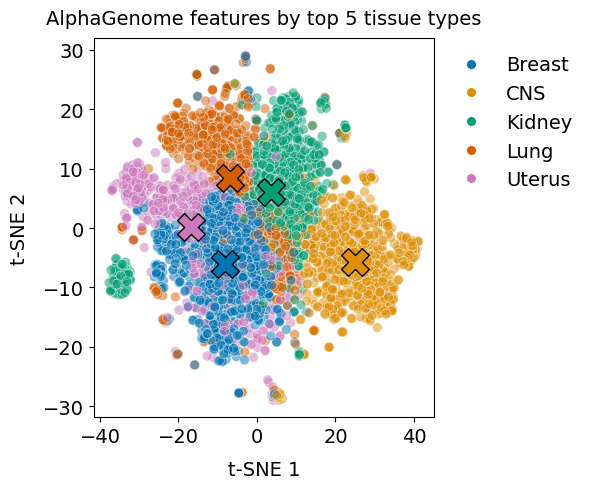

In [19]:
tissue_types = sorted(tsne_tissue_df["tissue"].unique())
tissue_palette = dict(zip(tissue_types, sns.color_palette("colorblind", n_colors=len(tissue_types))))
tsne_tissue_centroids_df = (
    tsne_tissue_df.groupby("tissue", as_index=False)[["tsne_1", "tsne_2"]]
    .mean()
)

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=tsne_tissue_df,
    x="tsne_1",
    y="tsne_2",
    hue="tissue",
    hue_order=tissue_types,
    palette=tissue_palette,
    s=50,
    alpha=0.5,
)

for _, centroid in tsne_tissue_centroids_df.iterrows():
    tissue = centroid["tissue"]
    plt.scatter(
        centroid["tsne_1"],
        centroid["tsne_2"],
        marker="X",
        s=400,
        color=tissue_palette[tissue],
        edgecolor="black",
    )

plt.xlabel("t-SNE 1", fontsize=14, labelpad=10)
plt.xticks(fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14, labelpad=10)
plt.yticks(fontsize=14)
plt.title("AlphaGenome features by top 5 tissue types", fontsize=14, pad=10)
legend = plt.legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=14, frameon=False)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
plt.savefig(os.path.join(AG_COX, "by_tissue_type.png"), dpi=300, bbox_inches="tight")
print_tsne_permanova(tsne_tissue_df, "tissue", "Tissue type", tissue_tsne_input_df)

## t-SNE clustering by cancer type

In [20]:
# Run t-SNE on the scaled Cox covariates for the top five cancer types by sample count.
tsne_feature_cols = cox_feature_cols
tsne_all_input_df = pd.concat(
    [train_df[tsne_feature_cols], test_df[tsne_feature_cols]],
    axis=0,
)
tsne_all_metadata_df = pd.concat(
    [
        train_df[["patient_id", "cancer_type"]].assign(split="train"),
        test_df[["patient_id", "cancer_type"]].assign(split="test"),
    ],
    axis=0,
)

top_5_cancer_types = tsne_all_metadata_df["cancer_type"].value_counts().head(5).index.tolist()
tsne_keep_mask = tsne_all_metadata_df["cancer_type"].isin(top_5_cancer_types)
tsne_input_df = tsne_all_input_df.loc[tsne_keep_mask].copy()
tsne_metadata_df = tsne_all_metadata_df.loc[tsne_keep_mask].copy()

tsne_perplexity = min(30, max(5, (len(tsne_input_df) - 1) // 3))
tsne_model = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
tsne_embedding = tsne_model.fit_transform(tsne_input_df)

tsne_df = tsne_metadata_df.copy()
tsne_df["tsne_1"] = tsne_embedding[:, 0]
tsne_df["tsne_2"] = tsne_embedding[:, 1]
tsne_df.to_csv(os.path.join(AG_COX, "top5_cancer_types_embedding.csv"), index=False)

print(f"Top five cancer types: {top_5_cancer_types}")
print(f"Computed t-SNE for {len(tsne_df)} patients using {len(tsne_feature_cols)} scaled features and perplexity={tsne_perplexity}.")
tsne_df.head()

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath

Top five cancer types: ['BRCA', 'KIRC', 'THCA', 'LGG', 'UCEC']
Computed t-SNE for 2782 patients using 630 scaled features and perplexity=30.


,patient_id,cancer_type,split,tsne_1,tsne_2
4579,TCGA-DE-A3KN,THCA,train,13.461181,-36.578392
5072,TCGA-E2-A15S,BRCA,train,26.646942,7.138867
5043,TCGA-E2-A14T,BRCA,train,4.122477,4.638389
4863,TCGA-DU-A5TU,LGG,train,-28.162519,11.943438
2569,TCGA-B0-4837,KIRC,train,27.681017,31.735542


Top 5 cancer types PERMANOVA (t-SNE coordinates): pseudo-F=1676.180, p=0.001, permutations=999
Top 5 cancer types PERMANOVA (original scaled feature matrix): pseudo-F=93.169, p=0.001, permutations=999


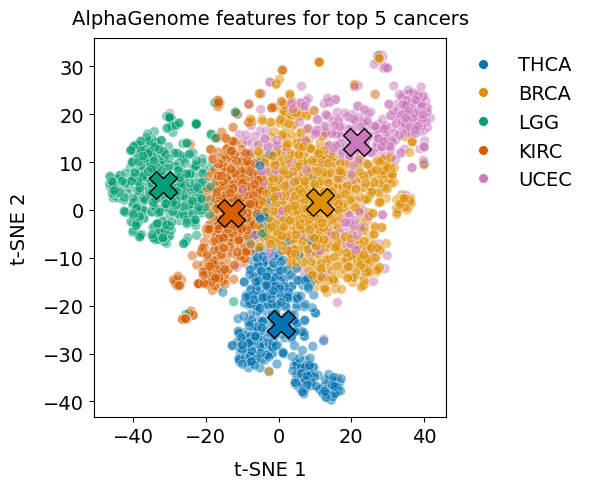

In [21]:
cancer_types = tsne_df["cancer_type"].unique()
cancer_palette = dict(zip(cancer_types, sns.color_palette("colorblind", n_colors=len(cancer_types))))
tsne_centroids_df = (
    tsne_df.groupby("cancer_type", as_index=False)[["tsne_1", "tsne_2"]]
    .mean()
)

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=tsne_df,
    x="tsne_1",
    y="tsne_2",
    hue="cancer_type",
    palette=cancer_palette,
    s=50,
    alpha=0.5,
)

for _, centroid in tsne_centroids_df.iterrows():
    cancer_type = centroid["cancer_type"]
    plt.scatter(
        centroid["tsne_1"],
        centroid["tsne_2"],
        marker="X",
        s=400,
        color=cancer_palette[cancer_type],
        edgecolor="black",
    )

plt.xlabel("t-SNE 1", fontsize=14, labelpad=10)
plt.xticks(fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14, labelpad=10)
plt.yticks(fontsize=14)
plt.title("AlphaGenome features for top 5 cancers", fontsize=14, pad=10)
legend = plt.legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=14, frameon=False)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
plt.savefig(os.path.join(AG_COX, "top5_cancer_types.png"), dpi=300, bbox_inches="tight")
print_tsne_permanova(tsne_df, "cancer_type", "Top 5 cancer types", tsne_input_df)


## t-SNE clustering by MSI-MSS status in COAD/READ

In [22]:
# Derive consensus MSI status using the thresholds from the MSI separability analysis.
msi_df = pd.read_csv(COAD_MSI_DATA)
msi_df = msi_df[["patient_barcode", "MSI_SCORE_MANTIS", "MSI_SENSOR_SCORE"]].copy()
msi_df = msi_df.rename(columns={"patient_barcode": "patient_id"})
msi_df = msi_df.dropna(subset=["MSI_SCORE_MANTIS", "MSI_SENSOR_SCORE"]).drop_duplicates()

msi_df["msi_status_mantis"] = np.where(msi_df["MSI_SCORE_MANTIS"] > 0.4, "MSI-H", "MSS")
msi_df["msi_status_sensor"] = np.where(msi_df["MSI_SENSOR_SCORE"] > 3.5, "MSI-H", "MSS")
msi_df["msi_consensus"] = np.where(
    msi_df["msi_status_mantis"] == msi_df["msi_status_sensor"],
    msi_df["msi_status_mantis"],
    "Discordant",
)
patient_msi_df = (
    msi_df[msi_df["msi_consensus"] != "Discordant"]
    .drop_duplicates(subset=["patient_id"], keep="first")
    [["patient_id", "msi_consensus"]]
)

msi_tsne_all_input_df = pd.concat(
    [train_df[cox_feature_cols], test_df[cox_feature_cols]],
    axis=0,
)
msi_tsne_all_metadata_df = pd.concat(
    [
        train_df[["patient_id", "cancer_type"]].assign(split="train"),
        test_df[["patient_id", "cancer_type"]].assign(split="test"),
    ],
    axis=0,
)
msi_tsne_all_metadata_df = msi_tsne_all_metadata_df.join(
    patient_msi_df.set_index("patient_id"),
    on="patient_id",
    validate="many_to_one",
)
msi_tsne_metadata_df = msi_tsne_all_metadata_df.dropna(subset=["msi_consensus"]).copy()
msi_tsne_input_df = msi_tsne_all_input_df.loc[msi_tsne_metadata_df.index].copy()

msi_tsne_perplexity = min(45, max(5, (len(msi_tsne_input_df) - 1) // 3))
msi_tsne_model = TSNE(
    n_components=2,
    perplexity=msi_tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
msi_tsne_embedding = msi_tsne_model.fit_transform(msi_tsne_input_df)

tsne_msi_df = msi_tsne_metadata_df.copy()
tsne_msi_df["tsne_1"] = msi_tsne_embedding[:, 0]
tsne_msi_df["tsne_2"] = msi_tsne_embedding[:, 1]
msi_order = [status for status in ["MSS", "MSI-H"] if status in tsne_msi_df["msi_consensus"].unique()]
tsne_msi_df["msi_consensus"] = pd.Categorical(tsne_msi_df["msi_consensus"], categories=msi_order, ordered=True)
tsne_msi_df.to_csv(os.path.join(AG_COX, "msi_mss.csv"), index=False)

print(f"Computed MSI/MSS t-SNE for {len(tsne_msi_df)} patients with perplexity={msi_tsne_perplexity}.")
print(tsne_msi_df["msi_consensus"].value_counts().sort_index())
tsne_msi_df.head()

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath

Computed MSI/MSS t-SNE for 378 patients with perplexity=45.
msi_consensus
MSS      328
MSI-H     50
Name: count, dtype: int64


,patient_id,cancer_type,split,msi_consensus,tsne_1,tsne_2
5410,TCGA-EI-6917,READ,train,MSS,5.150904,-2.152465
2019,TCGA-AA-3837,COAD,train,MSS,-5.703477,1.066202
2061,TCGA-AA-3986,COAD,train,MSS,3.306975,-4.700957
4215,TCGA-D5-6529,COAD,train,MSS,2.619472,-2.351363
2260,TCGA-AM-5821,COAD,train,MSI-H,-3.345215,10.098353


COAD/READ MSI-MSS status PERMANOVA (t-SNE coordinates): pseudo-F=161.449, p=0.001, permutations=999
COAD/READ MSI-MSS status PERMANOVA (original scaled feature matrix): pseudo-F=45.180, p=0.001, permutations=999


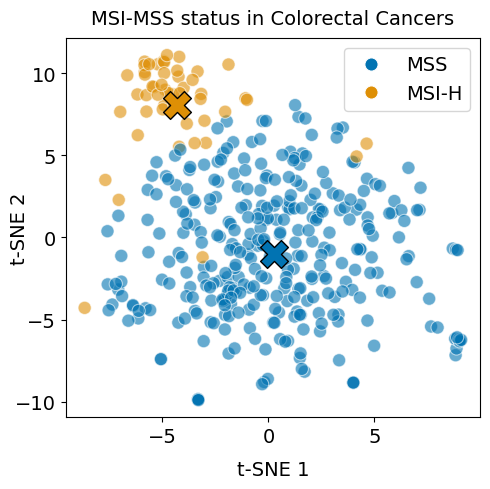

In [23]:
msi_palette = dict(zip(msi_order, sns.color_palette("colorblind", n_colors=len(msi_order))))
tsne_msi_centroids_df = (
    tsne_msi_df.groupby("msi_consensus", observed=True, as_index=False)[["tsne_1", "tsne_2"]]
    .mean()
)

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=tsne_msi_df,
    x="tsne_1",
    y="tsne_2",
    hue="msi_consensus",
    hue_order=msi_order,
    palette=msi_palette,
    s=90,
    alpha=0.6,
)

for _, centroid in tsne_msi_centroids_df.iterrows():
    msi_status = centroid["msi_consensus"]
    plt.scatter(
        centroid["tsne_1"],
        centroid["tsne_2"],
        marker="X",
        s=400,
        color=msi_palette[msi_status],
        edgecolor="black",
        zorder=5,
    )

plt.xlabel("t-SNE 1", fontsize=14, labelpad=10)
plt.xticks(fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14, labelpad=-10)
plt.yticks(fontsize=14)
plt.gca().locator_params(axis="x", nbins=5)
plt.title("MSI-MSS status in Colorectal Cancers", fontsize=14, pad=10)
legend = plt.legend(loc="upper right", fontsize=14, frameon=True)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
plt.savefig(os.path.join(AG_COX, "COAD_READ_msi_mss.png"), dpi=300, bbox_inches="tight")
print_tsne_permanova(tsne_msi_df, "msi_consensus", "COAD/READ MSI-MSS status", msi_tsne_input_df)

## t-SNE clustering by MSI-MSS status in UCEC

In [24]:
# Derive consensus UCEC MSI status from the 5-marker and 7-marker calls.
ucec_msi_df = pd.read_csv(UCEC_MSI_DATA)
ucec_msi_cols = ["MSI_STATUS_5_MARKER_CALL", "MSI_STATUS_7_MARKER_CALL"]
ucec_msi_df = ucec_msi_df[
    ["patient_barcode", *ucec_msi_cols]
].rename(columns={"patient_barcode": "patient_id"})
ucec_msi_df[ucec_msi_cols] = ucec_msi_df[ucec_msi_cols].apply(
    lambda column: column.astype("string").str.strip().str.upper()
)

# Treat MSI-L and MSS as non-MSI-high; require both marker panels to agree
# on MSI-H versus non-MSI-high and exclude missing/indeterminate calls.
valid_ucec_msi_calls = {"MSI-H", "MSI-L", "MSS"}
ucec_msi_df = ucec_msi_df[
    ucec_msi_df[ucec_msi_cols].isin(valid_ucec_msi_calls).all(axis=1)
].copy()
ucec_msi_df["msi_status_5_marker"] = np.where(
    ucec_msi_df["MSI_STATUS_5_MARKER_CALL"] == "MSI-H", "MSI-H", "MSS"
)
ucec_msi_df["msi_status_7_marker"] = np.where(
    ucec_msi_df["MSI_STATUS_7_MARKER_CALL"] == "MSI-H", "MSI-H", "MSS"
)
ucec_msi_df["msi_consensus"] = np.where(
    ucec_msi_df["msi_status_5_marker"] == ucec_msi_df["msi_status_7_marker"],
    ucec_msi_df["msi_status_5_marker"],
    "Discordant",
)
patient_ucec_msi_df = (
    ucec_msi_df[ucec_msi_df["msi_consensus"] != "Discordant"]
    .drop_duplicates(subset=["patient_id"], keep="first")
    [["patient_id", "msi_consensus"]]
)

ucec_msi_tsne_all_input_df = pd.concat(
    [train_df[cox_feature_cols], test_df[cox_feature_cols]], axis=0
)
ucec_msi_tsne_all_metadata_df = pd.concat(
    [
        train_df[["patient_id", "cancer_type"]].assign(split="train"),
        test_df[["patient_id", "cancer_type"]].assign(split="test"),
    ],
    axis=0,
)
ucec_msi_tsne_all_metadata_df = ucec_msi_tsne_all_metadata_df.join(
    patient_ucec_msi_df.set_index("patient_id"),
    on="patient_id",
    validate="many_to_one",
)
ucec_msi_tsne_metadata_df = ucec_msi_tsne_all_metadata_df[
    (ucec_msi_tsne_all_metadata_df["cancer_type"] == "UCEC")
    & ucec_msi_tsne_all_metadata_df["msi_consensus"].notna()
].copy()
ucec_msi_tsne_input_df = ucec_msi_tsne_all_input_df.loc[
    ucec_msi_tsne_metadata_df.index
].copy()

ucec_msi_order = [
    status for status in ["MSS", "MSI-H"]
    if status in ucec_msi_tsne_metadata_df["msi_consensus"].unique()
]
if len(ucec_msi_order) < 2:
    raise ValueError("Both MSI-H and MSS UCEC groups are required for clustering.")

ucec_msi_tsne_perplexity = min(
    30, max(5, (len(ucec_msi_tsne_input_df) - 1) // 3)
)
ucec_msi_tsne_embedding = TSNE(
    n_components=2,
    perplexity=ucec_msi_tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(ucec_msi_tsne_input_df)

tsne_ucec_msi_df = ucec_msi_tsne_metadata_df.copy()
tsne_ucec_msi_df["tsne_1"] = ucec_msi_tsne_embedding[:, 0]
tsne_ucec_msi_df["tsne_2"] = ucec_msi_tsne_embedding[:, 1]
tsne_ucec_msi_df["msi_consensus"] = pd.Categorical(
    tsne_ucec_msi_df["msi_consensus"],
    categories=ucec_msi_order,
    ordered=True,
)
tsne_ucec_msi_df.to_csv(
    os.path.join(AG_COX, "UCEC_msi_mss.csv"), index=False
)

print(
    f"Computed UCEC MSI/MSS t-SNE for {len(tsne_ucec_msi_df)} patients "
    f"with perplexity={ucec_msi_tsne_perplexity}."
)
print(tsne_ucec_msi_df["msi_consensus"].value_counts().sort_index())
tsne_ucec_msi_df.head()

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath

Computed UCEC MSI/MSS t-SNE for 306 patients with perplexity=30.
msi_consensus
MSS      200
MSI-H    106
Name: count, dtype: int64


,patient_id,cancer_type,split,msi_consensus,tsne_1,tsne_2
5828,TCGA-EY-A1GC,UCEC,train,MSS,8.292847,4.797297
1806,TCGA-A5-A0GQ,UCEC,train,MSS,9.990939,-2.708760
4617,TCGA-DI-A1BU,UCEC,train,MSI-H,-11.882066,-2.690723
2202,TCGA-AJ-A23O,UCEC,train,MSI-H,-9.611507,3.366645
2360,TCGA-AP-A0LG,UCEC,train,MSI-H,-10.509788,0.548780


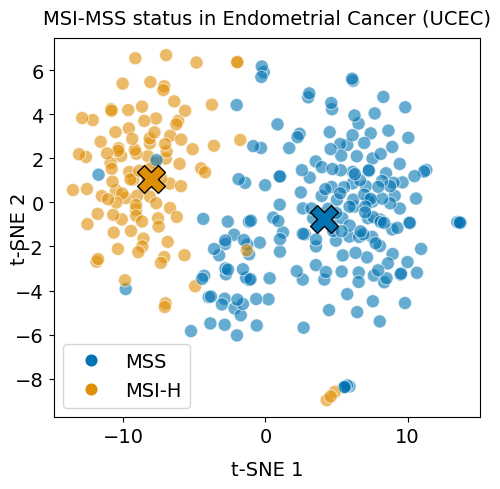

UCEC MSI-MSS status PERMANOVA (t-SNE coordinates): pseudo-F=388.593, p=0.001, permutations=999
UCEC MSI-MSS status PERMANOVA (original scaled feature matrix): pseudo-F=34.564, p=0.001, permutations=999


In [25]:
ucec_msi_palette = dict(
    zip(ucec_msi_order, sns.color_palette("colorblind", n_colors=len(ucec_msi_order)))
)
tsne_ucec_msi_centroids_df = (
    tsne_ucec_msi_df.groupby(
        "msi_consensus", observed=True, as_index=False
    )[["tsne_1", "tsne_2"]]
    .mean()
)

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=tsne_ucec_msi_df,
    x="tsne_1",
    y="tsne_2",
    hue="msi_consensus",
    hue_order=ucec_msi_order,
    palette=ucec_msi_palette,
    s=90,
    alpha=0.6,
)

for _, centroid in tsne_ucec_msi_centroids_df.iterrows():
    msi_status = centroid["msi_consensus"]
    plt.scatter(
        centroid["tsne_1"],
        centroid["tsne_2"],
        marker="X",
        s=400,
        color=ucec_msi_palette[msi_status],
        edgecolor="black",
        zorder=5,
    )

plt.xlabel("t-SNE 1", fontsize=14, labelpad=10)
plt.xticks(fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14, labelpad=-10)
plt.yticks(fontsize=14)
plt.gca().locator_params(axis="x", nbins=5)
plt.title("MSI-MSS status in Endometrial Cancer (UCEC)", fontsize=14, pad=10)
legend = plt.legend(loc="lower left", fontsize=14, frameon=True)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
plt.savefig(os.path.join(AG_COX, "UCEC_msi_mss.png"), dpi=300, bbox_inches="tight")
plt.show()
print_tsne_permanova(
    tsne_ucec_msi_df, "msi_consensus", "UCEC MSI-MSS status", ucec_msi_tsne_input_df
)

## t-SNE clustering by MSI-MSS status in STAD

In [26]:
# Treat MSI-L as MSS and retain patients with an informative STAD MSI call.
stad_msi_df = pd.read_csv(STAD_MSI_DATA, usecols=["patient_barcode", "MSI_STATUS"])
stad_msi_df = stad_msi_df.rename(columns={"patient_barcode": "patient_id"})
stad_msi_df["msi_status"] = (
    stad_msi_df["MSI_STATUS"].astype("string").str.strip().str.upper()
)
stad_msi_df = stad_msi_df[
    stad_msi_df["msi_status"].isin(["MSS", "MSI-L", "MSI-H"])
].copy()
stad_msi_df["msi_status"] = stad_msi_df["msi_status"].replace("MSI-L", "MSS")
patient_stad_msi_df = stad_msi_df.drop_duplicates(
    subset=["patient_id"], keep="first"
)[["patient_id", "msi_status"]]

stad_msi_tsne_all_input_df = pd.concat(
    [train_df[cox_feature_cols], test_df[cox_feature_cols]], axis=0
)
stad_msi_tsne_all_metadata_df = pd.concat(
    [
        train_df[["patient_id", "cancer_type"]].assign(split="train"),
        test_df[["patient_id", "cancer_type"]].assign(split="test"),
    ],
    axis=0,
)
stad_msi_tsne_all_metadata_df = stad_msi_tsne_all_metadata_df.join(
    patient_stad_msi_df.set_index("patient_id"),
    on="patient_id",
    validate="many_to_one",
)
stad_msi_tsne_metadata_df = stad_msi_tsne_all_metadata_df[
    (stad_msi_tsne_all_metadata_df["cancer_type"] == "STAD")
    & stad_msi_tsne_all_metadata_df["msi_status"].notna()
].copy()
stad_msi_tsne_input_df = stad_msi_tsne_all_input_df.loc[
    stad_msi_tsne_metadata_df.index
].copy()

stad_msi_order = [
    status for status in ["MSS", "MSI-H"]
    if status in stad_msi_tsne_metadata_df["msi_status"].unique()
]
if len(stad_msi_order) < 2:
    raise ValueError("Both MSI-H and MSS STAD groups are required for clustering.")

stad_msi_tsne_perplexity = min(
    30, max(5, (len(stad_msi_tsne_input_df) - 1) // 3)
)
stad_msi_tsne_embedding = TSNE(
    n_components=2,
    perplexity=stad_msi_tsne_perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(stad_msi_tsne_input_df)

tsne_stad_msi_df = stad_msi_tsne_metadata_df.copy()
tsne_stad_msi_df["tsne_1"] = stad_msi_tsne_embedding[:, 0]
tsne_stad_msi_df["tsne_2"] = stad_msi_tsne_embedding[:, 1]
tsne_stad_msi_df["msi_status"] = pd.Categorical(
    tsne_stad_msi_df["msi_status"], categories=stad_msi_order, ordered=True
)
tsne_stad_msi_df.to_csv(os.path.join(AG_COX, "STAD_msi_mss.csv"), index=False)

print(
    f"Computed STAD MSI/MSS t-SNE for {len(tsne_stad_msi_df)} patients "
    f"with perplexity={stad_msi_tsne_perplexity}."
)
print(tsne_stad_msi_df["msi_status"].value_counts().sort_index())
tsne_stad_msi_df.head()

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/sklearn/utils/extmath

Computed STAD MSI/MSS t-SNE for 262 patients with perplexity=30.
msi_status
MSS      209
MSI-H     53
Name: count, dtype: int64


,patient_id,cancer_type,split,msi_status,tsne_1,tsne_2
3293,TCGA-BR-8680,STAD,train,MSS,0.449195,5.337712
6666,TCGA-HU-A4H6,STAD,train,MSS,3.413320,9.204649
6090,TCGA-FP-8210,STAD,train,MSS,-3.622663,2.198681
3314,TCGA-BR-A4J7,STAD,train,MSS,-3.153041,2.762764
6091,TCGA-FP-A4BE,STAD,train,MSI-H,2.705245,-10.788078


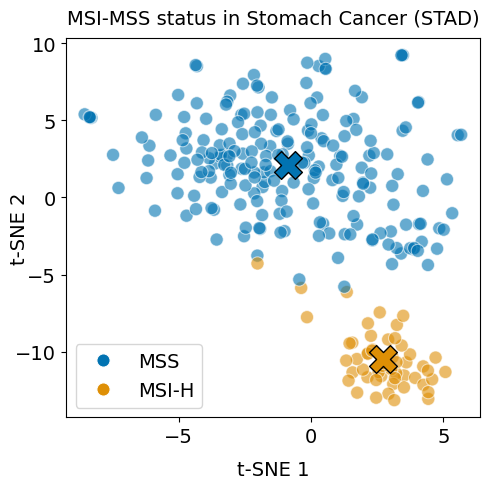

STAD MSI-MSS status PERMANOVA (t-SNE coordinates): pseudo-F=406.621, p=0.001, permutations=999
STAD MSI-MSS status PERMANOVA (original scaled feature matrix): pseudo-F=58.294, p=0.001, permutations=999


In [27]:
stad_msi_palette = dict(
    zip(stad_msi_order, sns.color_palette("colorblind", n_colors=len(stad_msi_order)))
)
tsne_stad_msi_centroids_df = (
    tsne_stad_msi_df.groupby("msi_status", observed=True, as_index=False)[
        ["tsne_1", "tsne_2"]
    ].mean()
)

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=tsne_stad_msi_df,
    x="tsne_1",
    y="tsne_2",
    hue="msi_status",
    hue_order=stad_msi_order,
    palette=stad_msi_palette,
    s=90,
    alpha=0.6,
)

for _, centroid in tsne_stad_msi_centroids_df.iterrows():
    msi_status = centroid["msi_status"]
    plt.scatter(
        centroid["tsne_1"],
        centroid["tsne_2"],
        marker="X",
        s=400,
        color=stad_msi_palette[msi_status],
        edgecolor="black",
        zorder=5,
    )

plt.xlabel("t-SNE 1", fontsize=14, labelpad=10)
plt.xticks(fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14, labelpad=-10)
plt.yticks(fontsize=14)
plt.gca().locator_params(axis="x", nbins=5)
plt.title("MSI-MSS status in Stomach Cancer (STAD)", fontsize=14, pad=10)
legend = plt.legend(loc="lower left", fontsize=14, frameon=True)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
plt.savefig(os.path.join(AG_COX, "STAD_msi_mss.png"), dpi=300, bbox_inches="tight")
plt.show()
print_tsne_permanova(
    tsne_stad_msi_df, "msi_status", "STAD MSI-MSS status", stad_msi_tsne_input_df
)

## MSI/MSS classifier comparison

Compare TMB-only, AlphaGenome-feature-only, and TMB-residualized AlphaGenome feature classifiers separately for COAD/READ, UCEC, and STAD using identical stratified cross-validation folds. Residualization parameters are learned within each training fold.

In [28]:
alphagenome_msi_classifier_results, alphagenome_msi_predictions = (
    msi_classifier.run_msi_benchmarks(
        feature_df=combined_scores,
        coad_msi_path=COAD_MSI_DATA,
        ucec_msi_path=UCEC_MSI_DATA,
        stad_msi_path=STAD_MSI_DATA,
        tmb_dir=TMB_DATA_DIR,
        out_dir=Path(AG_COX) / "msi_classifier",
        feature_name="AlphaGenome",
    )
)
alphagenome_msi_classifier_results.sort_values(["cohort", "roc_auc"], ascending=[True, False])

,cohort,model,n_folds,n,n_mss,n_msi_h,roc_auc,average_precision,accuracy,balanced_accuracy,f1,sensitivity,specificity
1,COAD_READ,AlphaGenome features,5,392,339,53,0.996772,0.988076,0.987245,0.960789,0.951456,0.924528,0.997050
0,COAD_READ,TMB only,5,392,339,53,0.974620,0.763056,0.964286,0.923638,0.867925,0.867925,0.979351
2,COAD_READ,AlphaGenome features residualized against TMB,5,392,339,53,0.927422,0.817097,0.926020,0.845801,0.728972,0.735849,0.955752
7,STAD,AlphaGenome features,5,284,223,61,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,STAD,TMB only,5,284,223,61,0.994119,0.962383,0.982394,0.976880,0.959350,0.967213,0.986547
8,STAD,AlphaGenome features residualized against TMB,5,284,223,61,0.870396,0.644038,0.806338,0.769499,0.609929,0.704918,0.834081
4,UCEC,AlphaGenome features,5,306,200,106,0.983113,0.983329,0.967320,0.963915,0.952830,0.952830,0.975000
5,UCEC,AlphaGenome features residualized against TMB,5,306,200,106,0.931274,0.927284,0.901961,0.896179,0.861111,0.877358,0.915000
3,UCEC,TMB only,5,306,200,106,0.893396,0.656905,0.836601,0.819575,0.764151,0.764151,0.875000


In [29]:
alphagenome_msi_metric_table = alphagenome_msi_classifier_results.pivot(
    index="cohort",
    columns="model",
    values=["roc_auc", "average_precision", "balanced_accuracy", "f1"],
)
alphagenome_msi_metric_table

roc_auc                                                \
model     AlphaGenome features AlphaGenome features residualized against TMB   
cohort                                                                         
COAD_READ             0.996772                                      0.927422   
STAD                  1.000000                                      0.870396   
UCEC                  0.983113                                      0.931274   

                       average_precision  \
model      TMB only AlphaGenome features   
cohort                                     
COAD_READ  0.974620             0.988076   
STAD       0.994119             1.000000   
UCEC       0.893396             0.983329   

                                                                   \
model     AlphaGenome features residualized against TMB  TMB only   
cohort                                                              
COAD_READ                                      0.817097  0.763056   
STAD                                           0.644038  0.962383   
UCEC                                           0.927284  0.656905   

             balanced_accuracy                                                \
model     AlphaGenome features AlphaGenome features residualized against TMB   
cohort                                                                         
COAD_READ             0.960789                                      0.845801   
STAD                  1.000000                                      0.769499   
UCEC                  0.963915                                      0.896179   

                                      f1  \
model      TMB only AlphaGenome features   
cohort                                     
COAD_READ  0.923638             0.951456   
STAD       0.976880             1.000000   
UCEC       0.819575             0.952830   

                                                                   
model     AlphaGenome features residualized against TMB  TMB only  
cohort                                                             
COAD_READ                                      0.728972  0.867925  
STAD                                           0.609929  0.959350  
UCEC                                           0.861111  0.764151

COAD/READ | TMB only: AUPRC=0.763
COAD/READ | AlphaGenome features residualized against TMB: AUPRC=0.817
COAD/READ | AlphaGenome features: AUPRC=0.988
UCEC | TMB only: AUPRC=0.657
UCEC | AlphaGenome features residualized against TMB: AUPRC=0.927
UCEC | AlphaGenome features: AUPRC=0.983
STAD | TMB only: AUPRC=0.962
STAD | AlphaGenome features residualized against TMB: AUPRC=0.644
STAD | AlphaGenome features: AUPRC=1.000


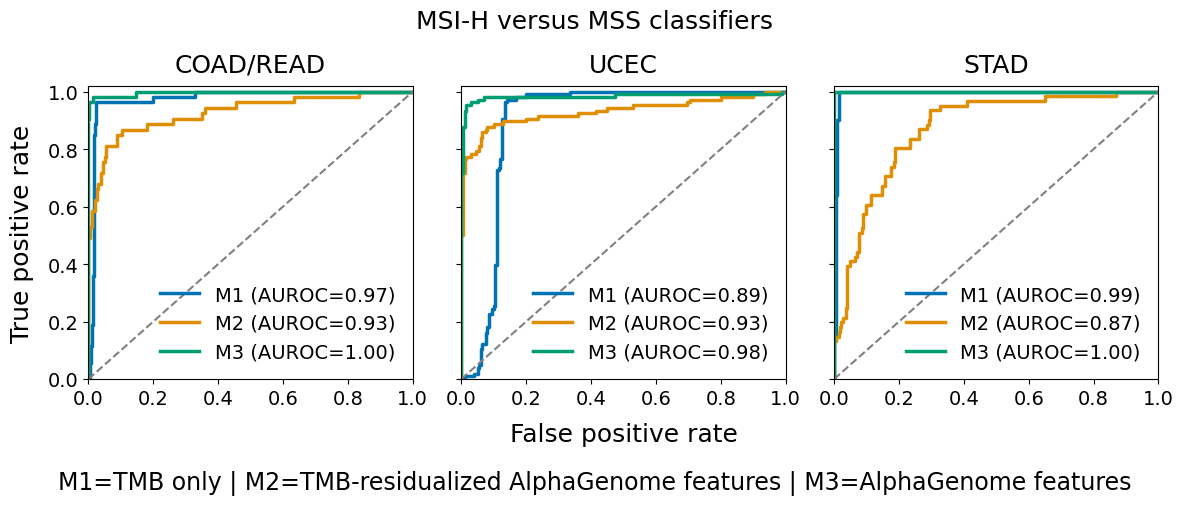

In [30]:
alphagenome_msi_model_order = [
    "TMB only",
    "AlphaGenome features residualized against TMB",
    "AlphaGenome features",
]
alphagenome_msi_palette = dict(
    zip(
        alphagenome_msi_model_order,
        sns.color_palette("colorblind", n_colors=len(alphagenome_msi_model_order)),
    )
)
alphagenome_msi_model_labels = dict(
    zip(alphagenome_msi_model_order, ["M1", "M2", "M3"])
)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
for panel_index, (ax, cohort) in enumerate(zip(axes, ["COAD_READ", "UCEC", "STAD"])):
    cohort_predictions = alphagenome_msi_predictions[
        alphagenome_msi_predictions["cohort"] == cohort
    ]
    for model_name in alphagenome_msi_model_order:
        model_predictions = cohort_predictions[
            cohort_predictions["model"] == model_name
        ]
        fpr, tpr, _ = roc_curve(
            model_predictions["msi_label"],
            model_predictions["predicted_probability"],
        )
        auc = roc_auc_score(
            model_predictions["msi_label"],
            model_predictions["predicted_probability"],
        )
        auprc = average_precision_score(
            model_predictions["msi_label"],
            model_predictions["predicted_probability"],
        )
        print(f"{cohort.replace('_', '/')} | {model_name}: AUPRC={auprc:.3f}")
        ax.plot(
            fpr,
            tpr,
            color=alphagenome_msi_palette[model_name],
            linewidth=2.5,
            label=f"{alphagenome_msi_model_labels[model_name]} (AUROC={auc:.2f})",
        )
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1.5)
    ax.set_title(cohort.replace("_", "/"), fontsize=18, pad=10)
    ax.set_xlabel("False positive rate" if panel_index == 1 else "", fontsize=18, labelpad=10)
    ax.set_ylabel("True positive rate" if panel_index == 0 else "", fontsize=18, labelpad=10)
    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=14, frameon=False, loc="lower right")

fig.suptitle("MSI-H versus MSS classifiers", fontsize=18)
fig.tight_layout()
fig.subplots_adjust(wspace=0.15, bottom=0.24)
fig.text(
    0.5, 0.02,
    "M1=TMB only | M2=TMB-residualized AlphaGenome features | M3=AlphaGenome features",
    ha="center", fontsize=17,
)
fig.savefig(
    Path(AG_COX) / "msi_classifier" / "msi_classifier_roc_curves.png",
    dpi=300,
    bbox_inches="tight",
)

MSI/MSS class balance:
COAD/READ: MSI-H=53, MSS=339, MSI-H prevalence=13.5%
UCEC: MSI-H=106, MSS=200, MSI-H prevalence=34.6%
STAD: MSI-H=61, MSS=223, MSI-H prevalence=21.5%


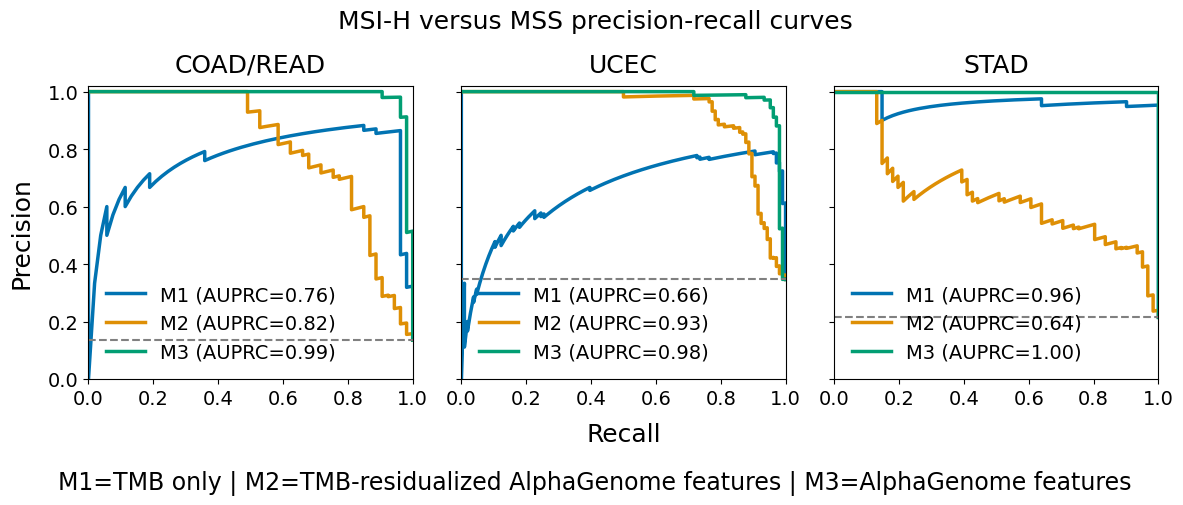

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
for panel_index, (ax, cohort) in enumerate(zip(axes, ["COAD_READ", "UCEC", "STAD"])):
    cohort_predictions = alphagenome_msi_predictions[
        alphagenome_msi_predictions["cohort"] == cohort
    ]
    for model_name in alphagenome_msi_model_order:
        model_predictions = cohort_predictions[
            cohort_predictions["model"] == model_name
        ]
        precision, recall, _ = precision_recall_curve(
            model_predictions["msi_label"],
            model_predictions["predicted_probability"],
        )
        auprc = average_precision_score(
            model_predictions["msi_label"],
            model_predictions["predicted_probability"],
        )
        ax.plot(
            recall,
            precision,
            color=alphagenome_msi_palette[model_name],
            linewidth=2.5,
            label=f"{alphagenome_msi_model_labels[model_name]} (AUPRC={auprc:.2f})",
        )
    baseline = cohort_predictions["msi_label"].mean()
    ax.axhline(baseline, linestyle="--", color="grey", linewidth=1.5)
    ax.set_title(cohort.replace("_", "/"), fontsize=18, pad=10)
    ax.set_xlabel("Recall" if panel_index == 1 else "", fontsize=18, labelpad=10)
    ax.set_ylabel("Precision" if panel_index == 0 else "", fontsize=18, labelpad=10)
    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=14, frameon=False, loc="lower left")

fig.suptitle("MSI-H versus MSS precision-recall curves", fontsize=18)
fig.tight_layout()
fig.subplots_adjust(wspace=0.15, bottom=0.24)
fig.text(
    0.5, 0.02,
    "M1=TMB only | M2=TMB-residualized AlphaGenome features | M3=AlphaGenome features",
    ha="center", fontsize=17,
)
fig.savefig(
    Path(AG_COX) / "msi_classifier" / "msi_classifier_precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight",
)

print("MSI/MSS class balance:")
for cohort in ["COAD_READ", "UCEC", "STAD"]:
    cohort_labels = (
        alphagenome_msi_predictions[alphagenome_msi_predictions["cohort"] == cohort]
        .drop_duplicates("patient_id")
    )
    counts = cohort_labels["msi_label"].value_counts()
    msi_h = counts.get(1, 0)
    mss = counts.get(0, 0)
    print(
        f"{cohort.replace('_', '/')}: MSI-H={msi_h}, MSS={mss}, "
        f"MSI-H prevalence={msi_h / (msi_h + mss):.1%}"
    )